<a href="https://www.kaggle.com/code/omborse771924/nyc-regents-exam-dataset-eda-features-engineering?scriptVersionId=337902678" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/razanihababdellatif/nyc-regents-exam-dataset/2014-15_to_2017-19_NYC_Regents_Exam_Results_-_Public_20260724.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/razanihababdellatif/nyc-regents-exam-dataset/2014-15_to_2017-19_NYC_Regents_Exam_Results_-_Public_20260724.csv')

In [3]:
df.head()

,Unnamed Column,School DBN,School Name,School Type,School Level,Regents Exam,Year,Category,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,08X5072015All StudentsGeometry,08X507,Stevenson Yabc,YABC,High school,Geometry,2015,All Students,1,s,s,s,s,s,s,s,s,s
1,01M1842018All StudentsLiving Environment,01M184,P.S. 184m Shuang Wen,General Academic,K-8,Living Environment,2018,All Students,32,90.2,0,0.0,32,100.0,31,96.9,na,na
2,01M4582019All StudentsSpanish,01M458,Forsyth Satellite Academy,Transfer School,High school,Spanish,2019,All Students,1,s,s,s,s,s,s,s,s,s
3,01M5092017All StudentsSpanish,01M509,Marta Valle High School,General Academic,High school,Spanish,2017,All Students,16,82.7,0,0.0,16,100.0,10,62.5,na,na
4,02M2982015All StudentsGeometry,02M298,Pace High School,General Academic,High school,Geometry,2015,All Students,163,62.9,81,49.7,82,50.3,13,8.0,13,8.0


In [4]:
df.tail()

,Unnamed Column,School DBN,School Name,School Type,School Level,Regents Exam,Year,Category,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
33026,84X7172017All StudentsLiving Environment,84X717,Icahn Charter School,General Academic,K-8,Living Environment,2017,All Students,10,79.7,0,0.0,10,100.0,5,50.0,na,na
33027,84X7172018All StudentsCommon Core Algebra,84X717,Icahn Charter School,General Academic,K-8,Common Core Algebra,2018,All Students,15,86.9,0,0.0,15,100.0,15,100.0,15,100.0
33028,84X7172018All StudentsLiving Environment,84X717,Icahn Charter School,General Academic,K-8,Living Environment,2018,All Students,9,85.3,0,0.0,9,100.0,8,88.9,na,na
33029,84X7172019All StudentsCommon Core Algebra,84X717,Icahn Charter School,General Academic,K-8,Common Core Algebra,2019,All Students,15,93.2,0,0.0,15,100.0,15,100.0,15,100.0
33030,84X7172019All StudentsLiving Environment,84X717,Icahn Charter School,General Academic,K-8,Living Environment,2019,All Students,14,77.9,0,0.0,14,100.0,8,57.1,na,na


In [5]:
df.info

<bound method DataFrame.info of                                   Unnamed Column School DBN  \
0                 08X5072015All StudentsGeometry     08X507   
1       01M1842018All StudentsLiving Environment     01M184   
2                  01M4582019All StudentsSpanish     01M458   
3                  01M5092017All StudentsSpanish     01M509   
4                 02M2982015All StudentsGeometry     02M298   
...                                          ...        ...   
33026   84X7172017All StudentsLiving Environment     84X717   
33027  84X7172018All StudentsCommon Core Algebra     84X717   
33028   84X7172018All StudentsLiving Environment     84X717   
33029  84X7172019All StudentsCommon Core Algebra     84X717   
33030   84X7172019All StudentsLiving Environment     84X717   

                     School Name       School Type School Level  \
0                 Stevenson Yabc              YABC  High school   
1           P.S. 184m Shuang Wen  General Academic          K-8   
2      For

In [6]:
df.isnull()

,Unnamed Column,School DBN,School Name,School Type,School Level,Regents Exam,Year,Category,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33026,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
33027,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
33028,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
33029,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.describe

<bound method NDFrame.describe of                                   Unnamed Column School DBN  \
0                 08X5072015All StudentsGeometry     08X507   
1       01M1842018All StudentsLiving Environment     01M184   
2                  01M4582019All StudentsSpanish     01M458   
3                  01M5092017All StudentsSpanish     01M509   
4                 02M2982015All StudentsGeometry     02M298   
...                                          ...        ...   
33026   84X7172017All StudentsLiving Environment     84X717   
33027  84X7172018All StudentsCommon Core Algebra     84X717   
33028   84X7172018All StudentsLiving Environment     84X717   
33029  84X7172019All StudentsCommon Core Algebra     84X717   
33030   84X7172019All StudentsLiving Environment     84X717   

                     School Name       School Type School Level  \
0                 Stevenson Yabc              YABC  High school   
1           P.S. 184m Shuang Wen  General Academic          K-8   
2      F

In [8]:
df.isnull().sum()

Unnamed Column                 0
School DBN                     0
School Name                    0
School Type                    0
School Level                   0
Regents Exam                   0
Year                           0
Category                       0
Total Tested                   0
Mean Score                     0
Number Scoring Below 65        0
Percent Scoring Below 65       0
Number Scoring 65 or Above     0
Percent Scoring 65 or Above    0
Number Scoring 80 or Above     0
Percent Scoring 80 or Above    0
Number Scoring CR              0
Percent Scoring CR             0
dtype: int64

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
33026    False
33027    False
33028    False
33029    False
33030    False
Length: 33031, dtype: bool

In [10]:
df.duplicated().sum(
    
)

np.int64(0)

In [11]:
df.columns

Index(['Unnamed Column', 'School DBN', 'School Name', 'School Type',
       'School Level', 'Regents Exam', 'Year', 'Category', 'Total Tested',
       'Mean Score', 'Number Scoring Below 65', 'Percent Scoring Below 65',
       'Number Scoring 65 or Above', 'Percent Scoring 65 or Above',
       'Number Scoring 80 or Above', 'Percent Scoring 80 or Above',
       'Number Scoring CR', 'Percent Scoring CR'],
      dtype='object')

## EDA

  School DBN                School Name       School Type School Level  \
0     08X507             Stevenson Yabc              YABC  High school   
1     01M184       P.S. 184m Shuang Wen  General Academic          K-8   
2     01M458  Forsyth Satellite Academy   Transfer School  High school   
3     01M509    Marta Valle High School  General Academic  High school   
4     02M298           Pace High School  General Academic  High school   

         Regents Exam  Year      Category Total Tested Mean Score  \
0            Geometry  2015  All Students            1          s   
1  Living Environment  2018  All Students           32       90.2   
2             Spanish  2019  All Students            1          s   
3             Spanish  2017  All Students           16       82.7   
4            Geometry  2015  All Students          163       62.9   

  Number Scoring Below 65 Percent Scoring Below 65 Number Scoring 65 or Above  \
0                       s                        s         

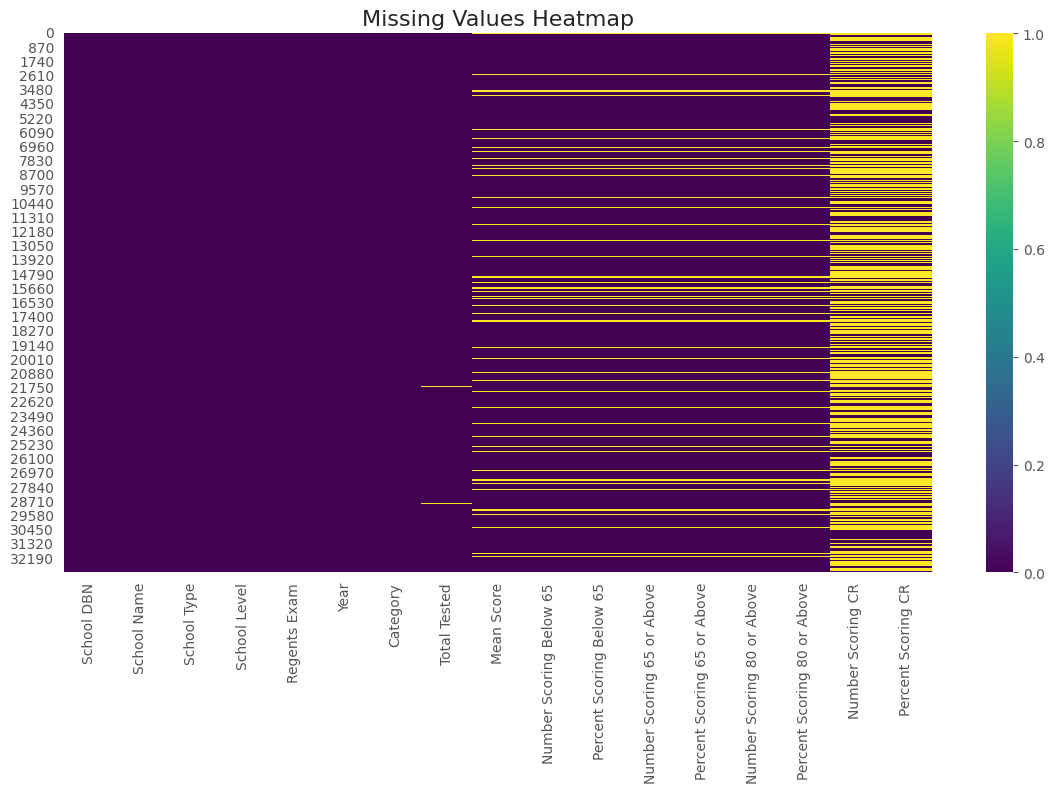

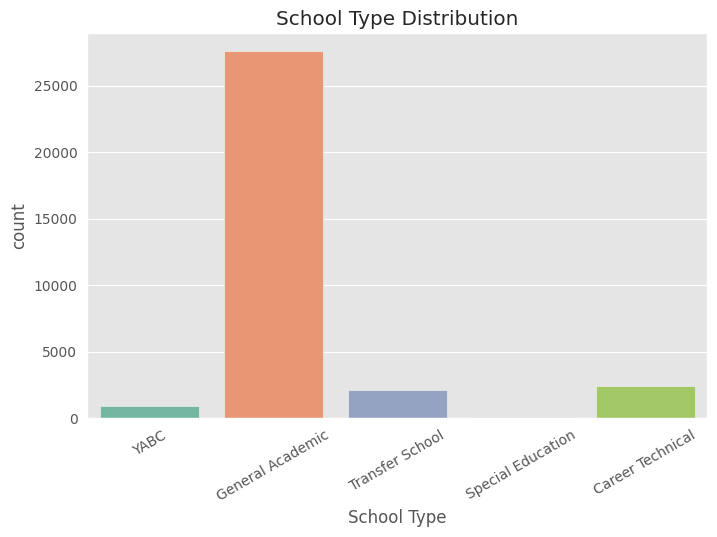

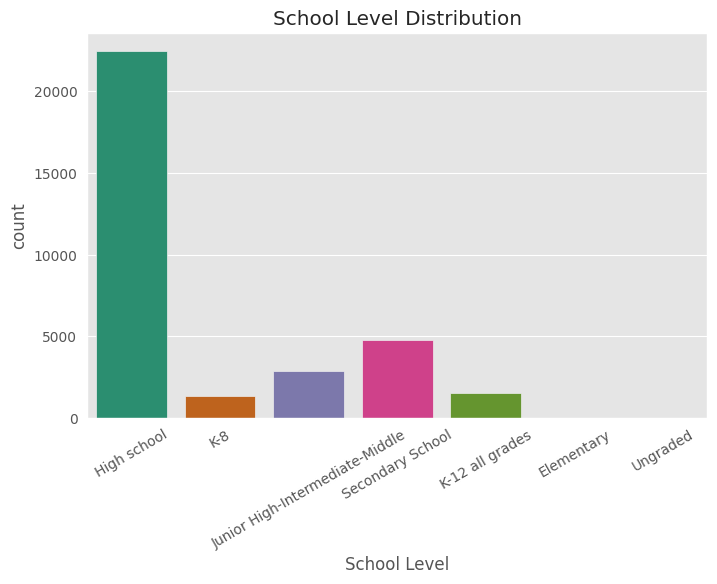

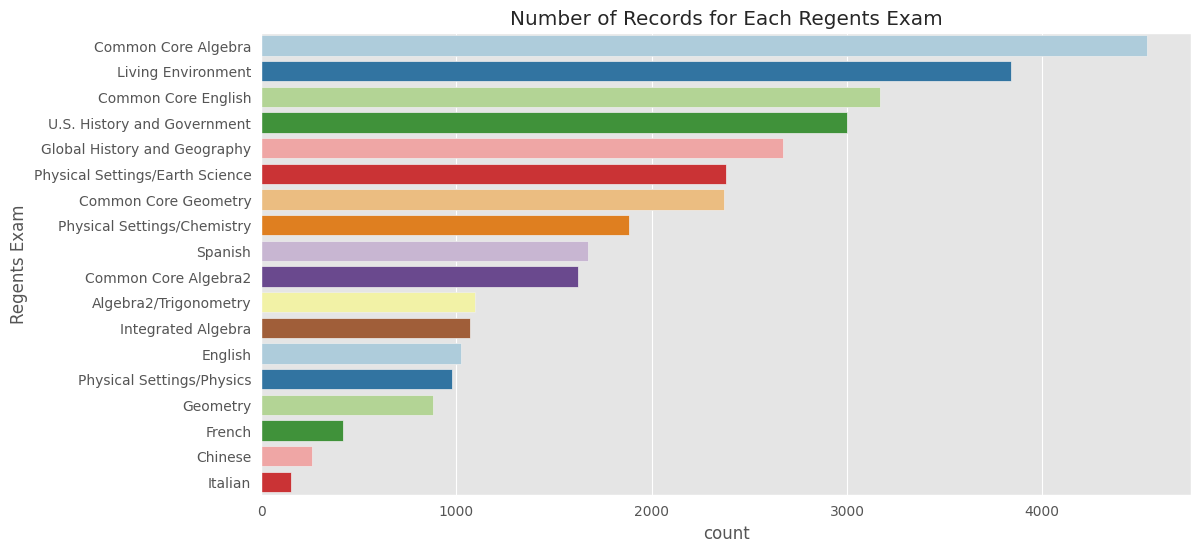

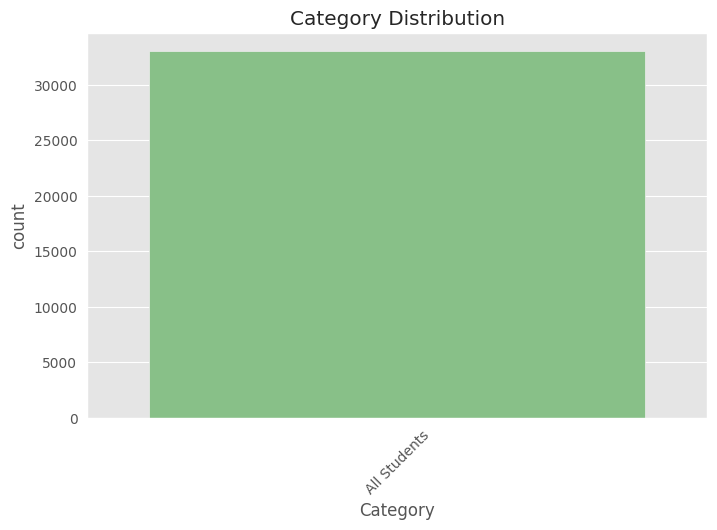

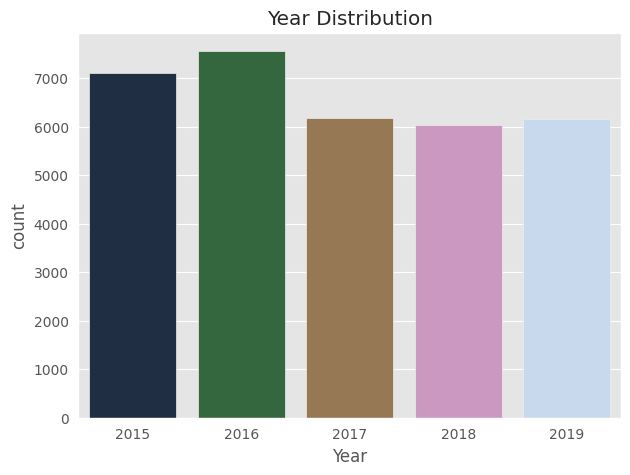

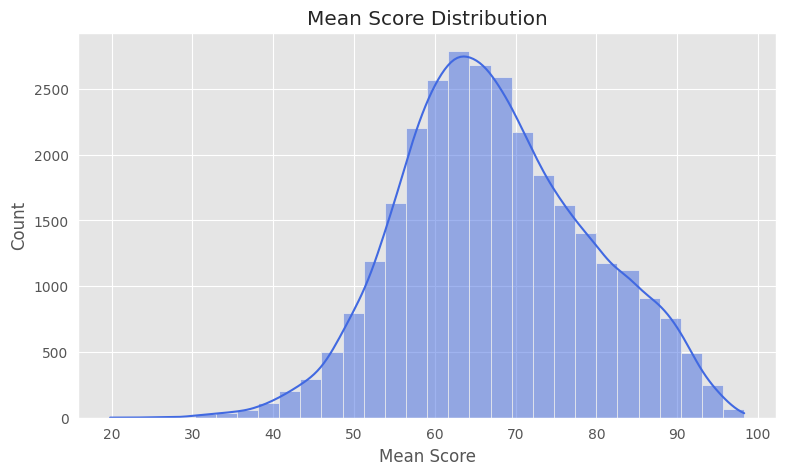

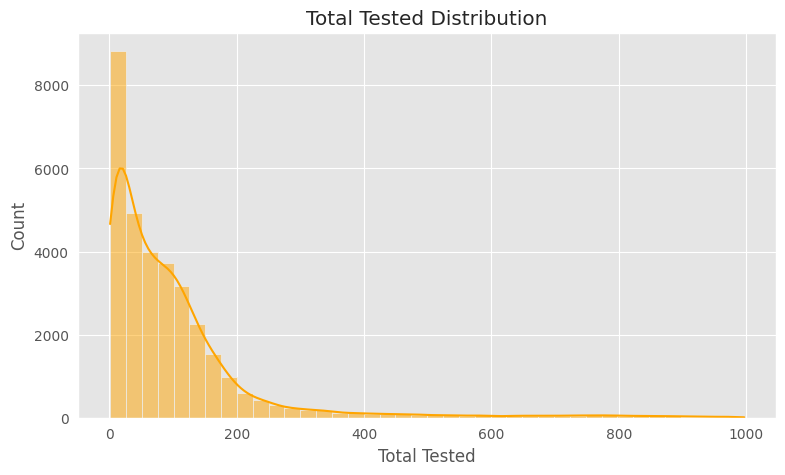

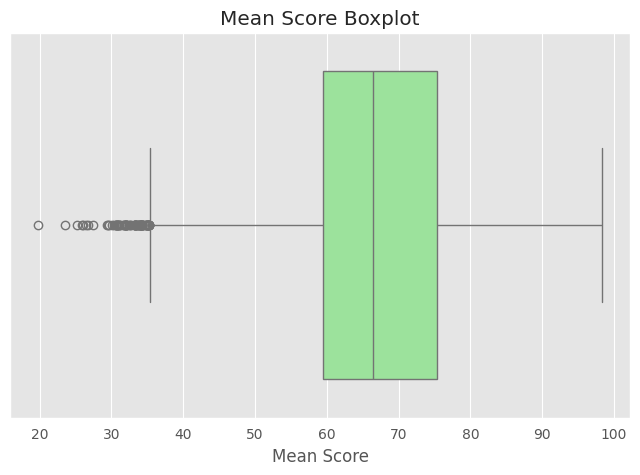

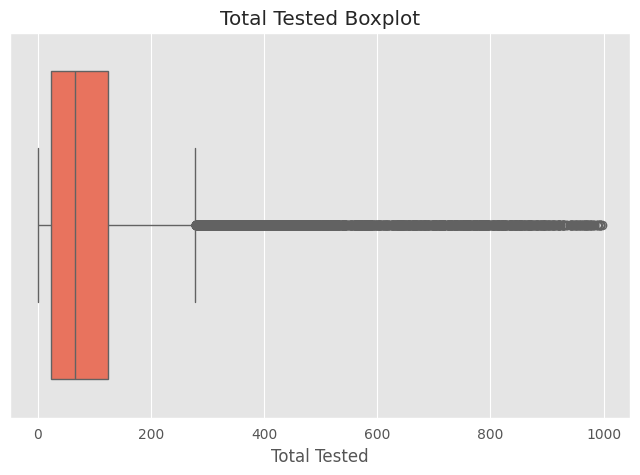

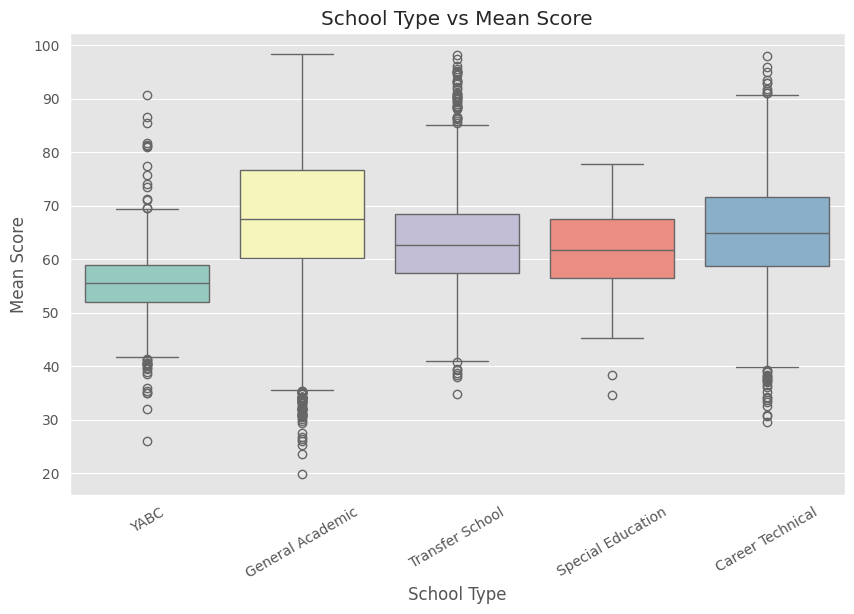

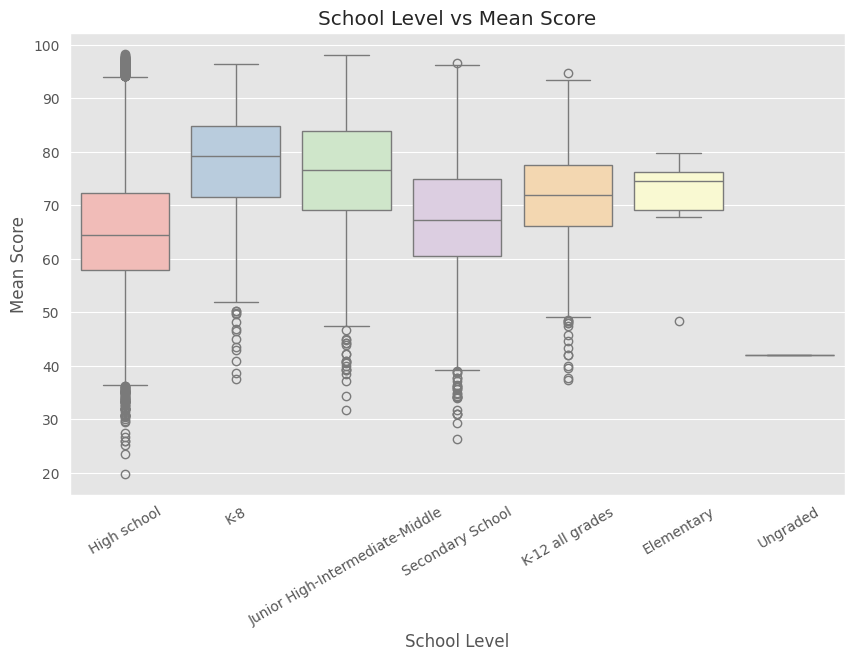

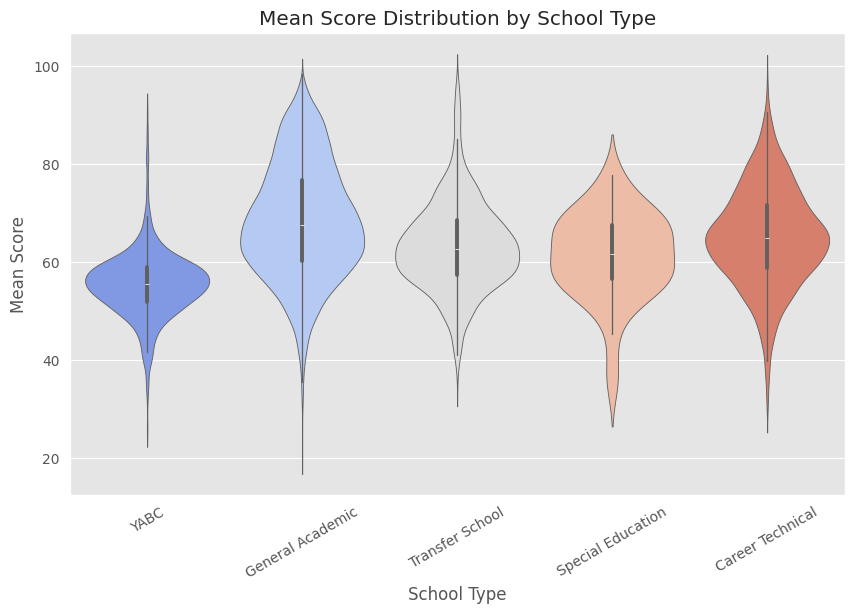

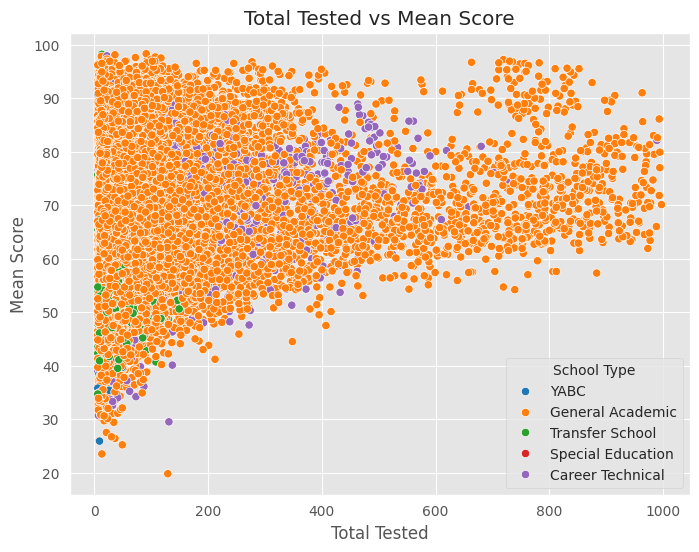

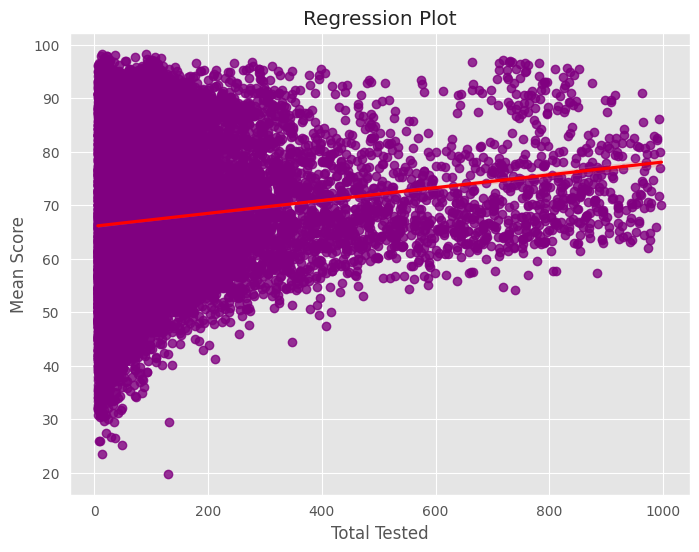

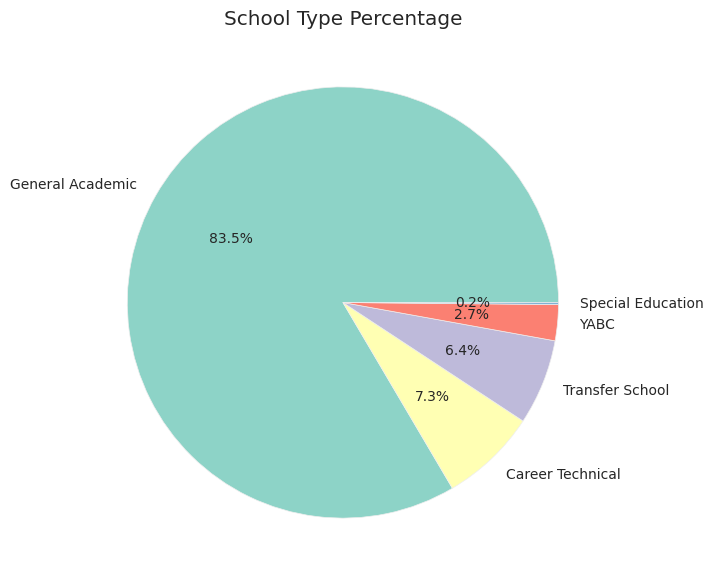

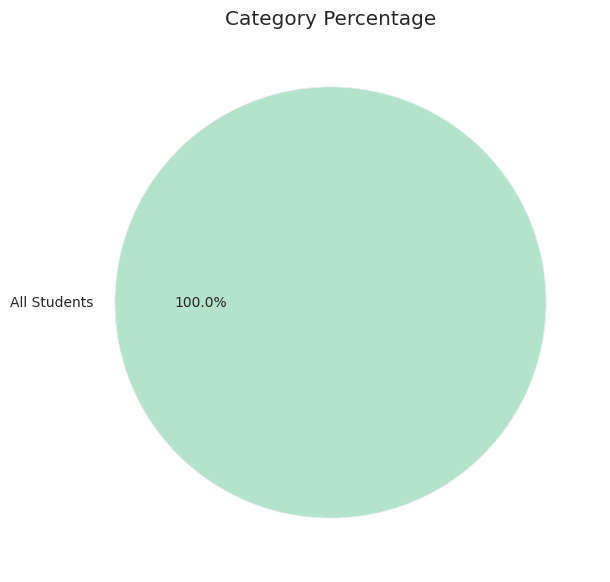

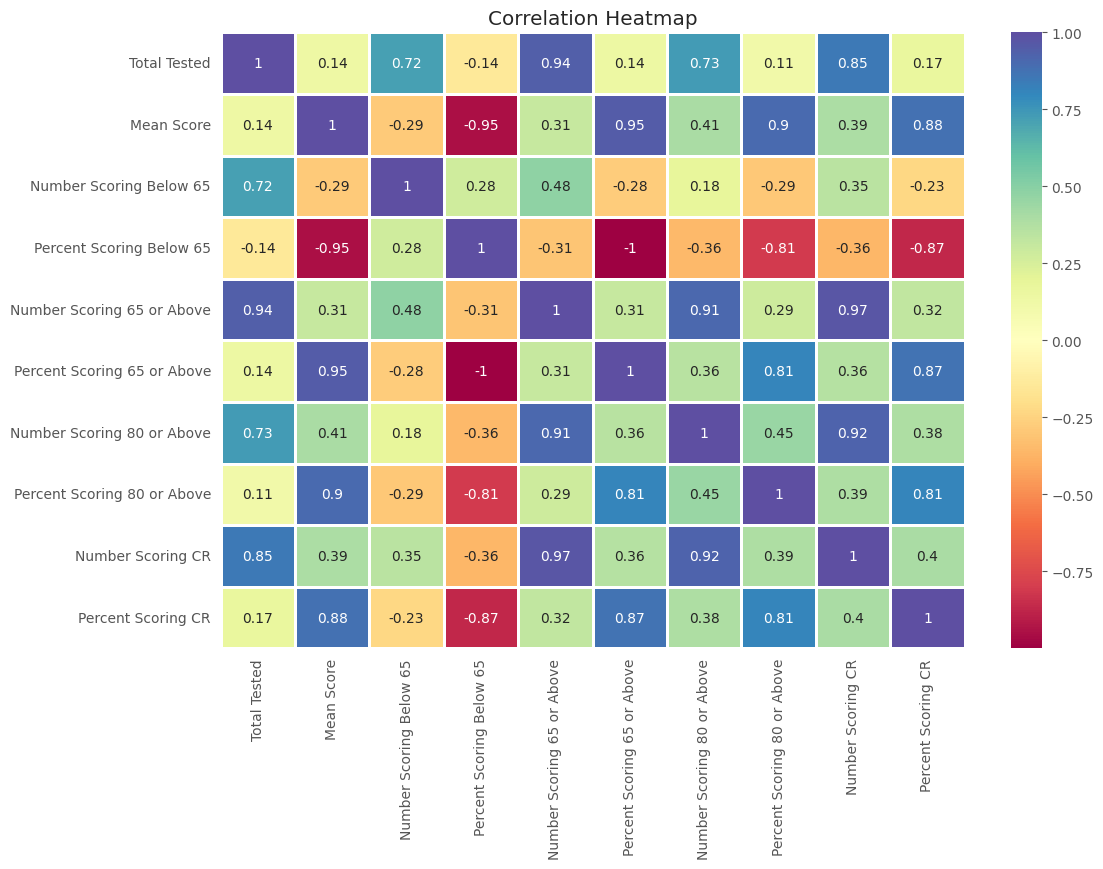

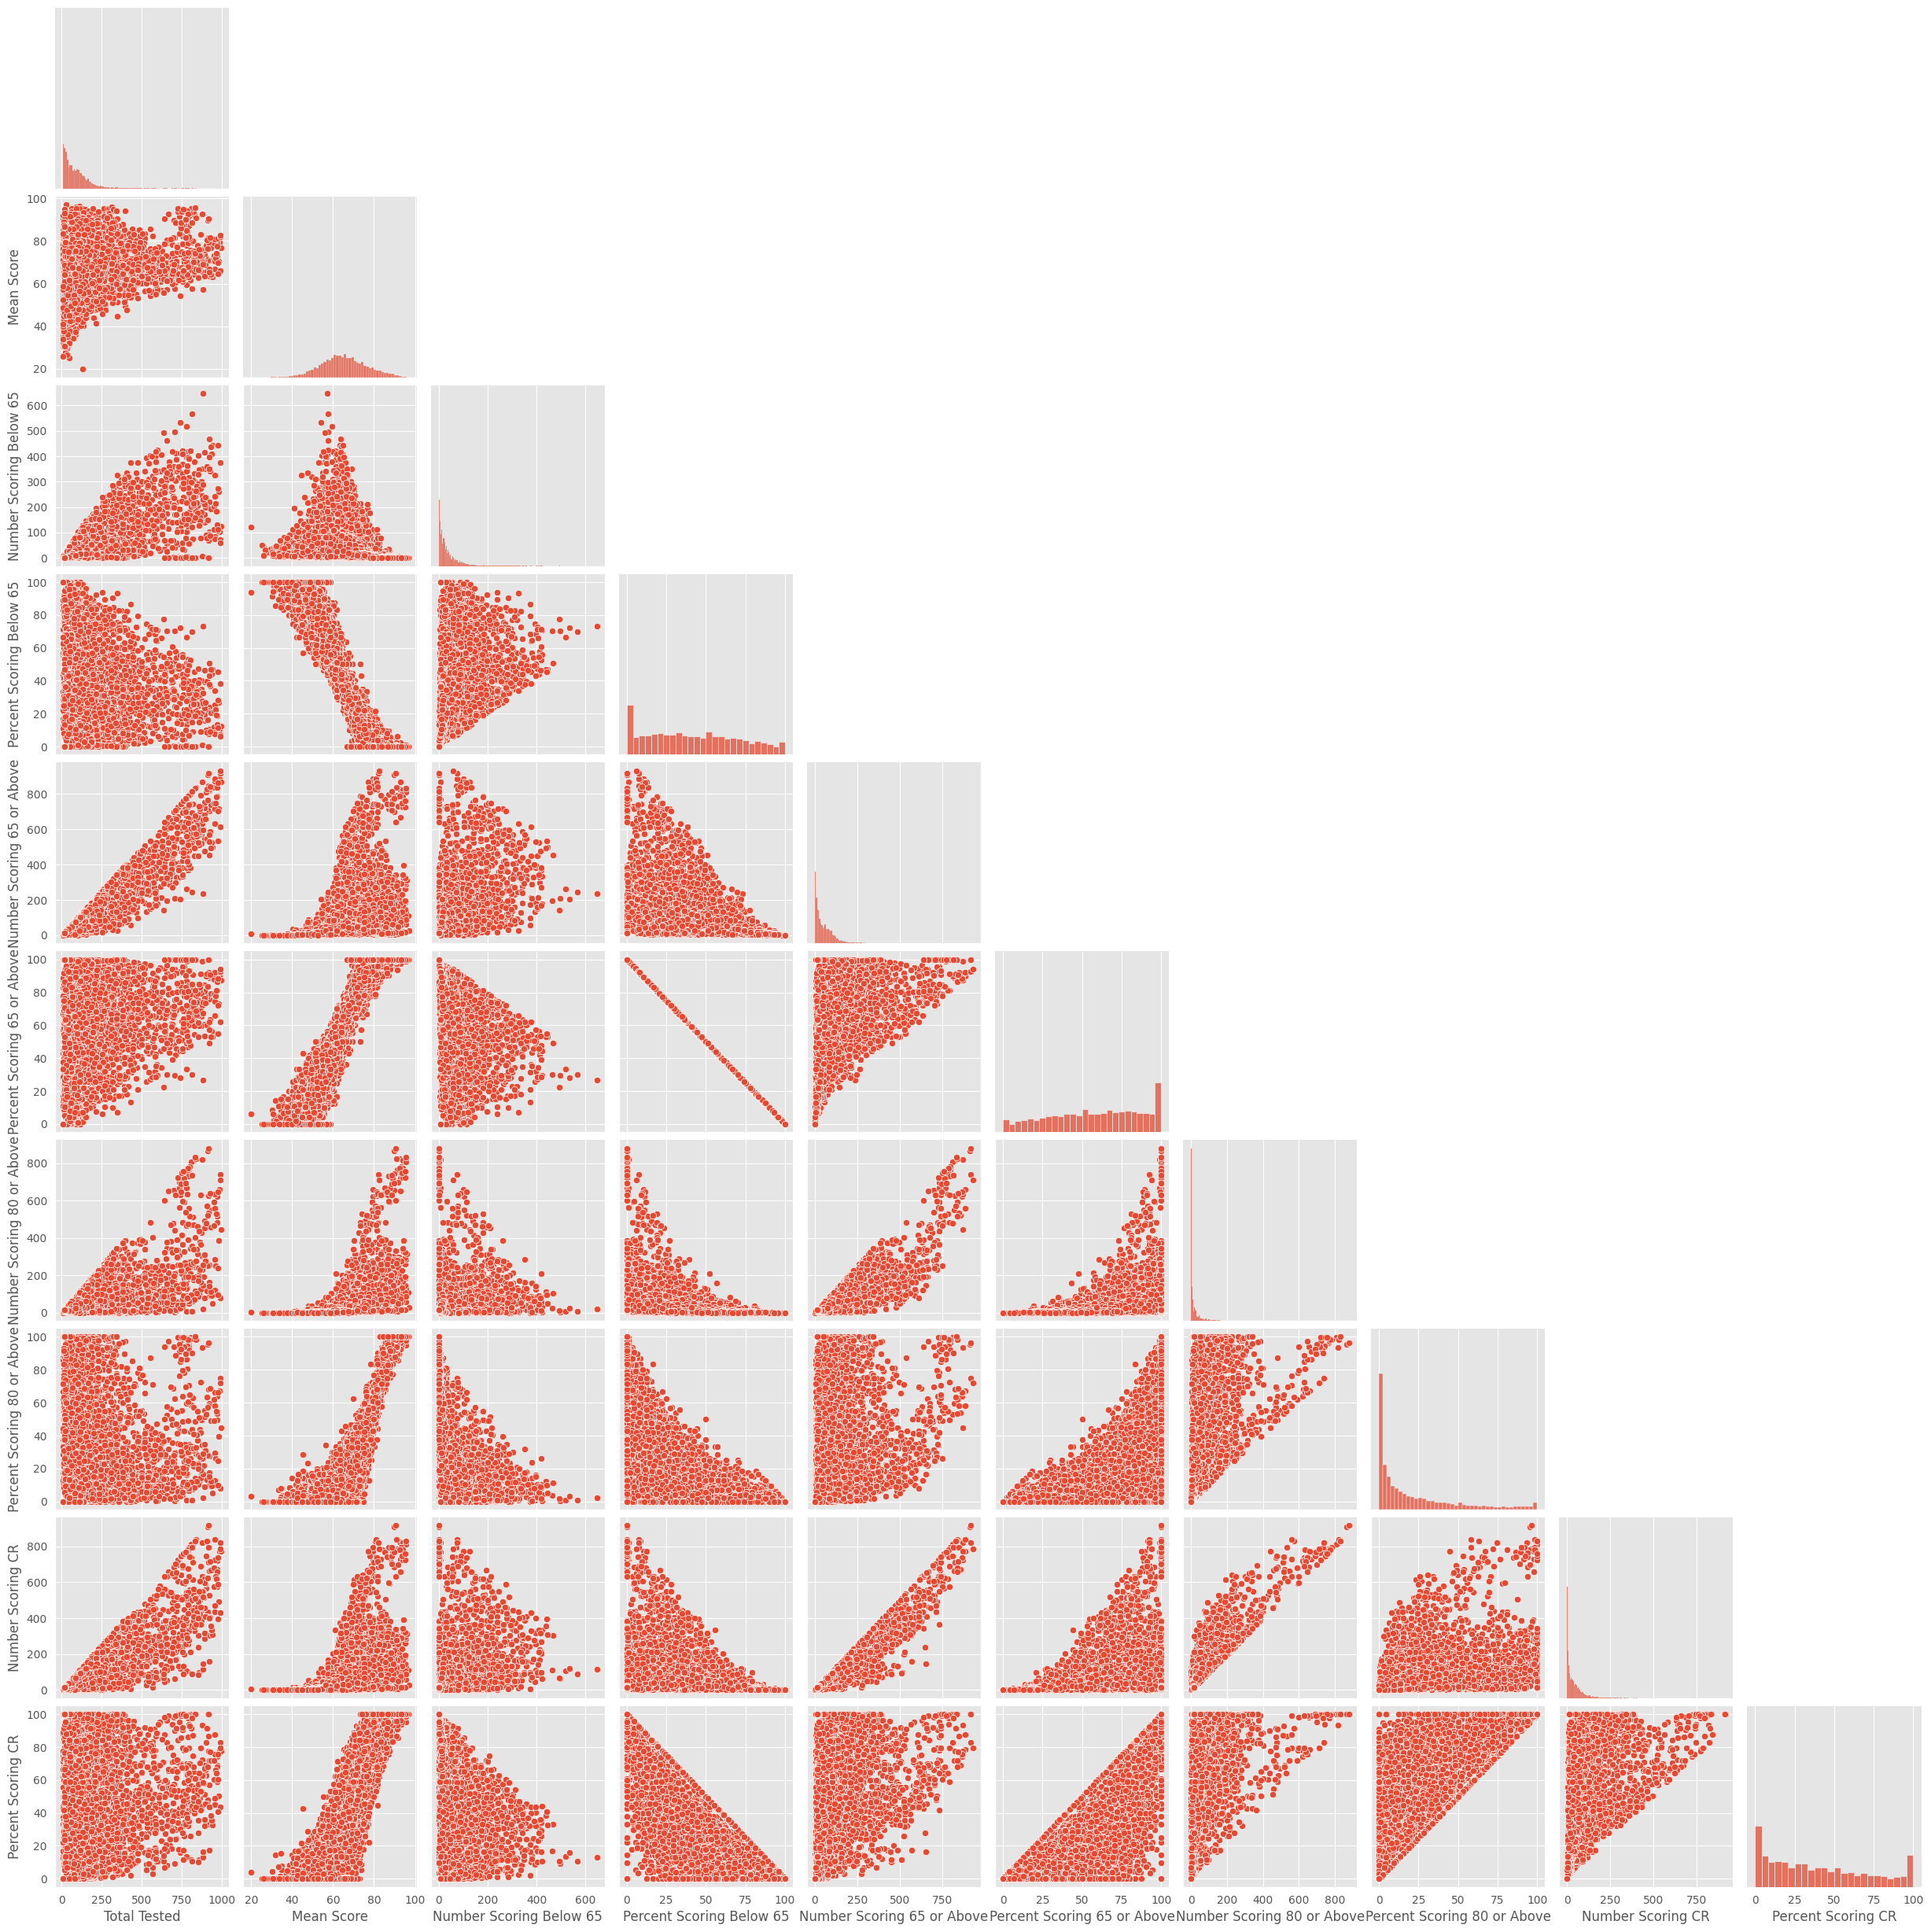

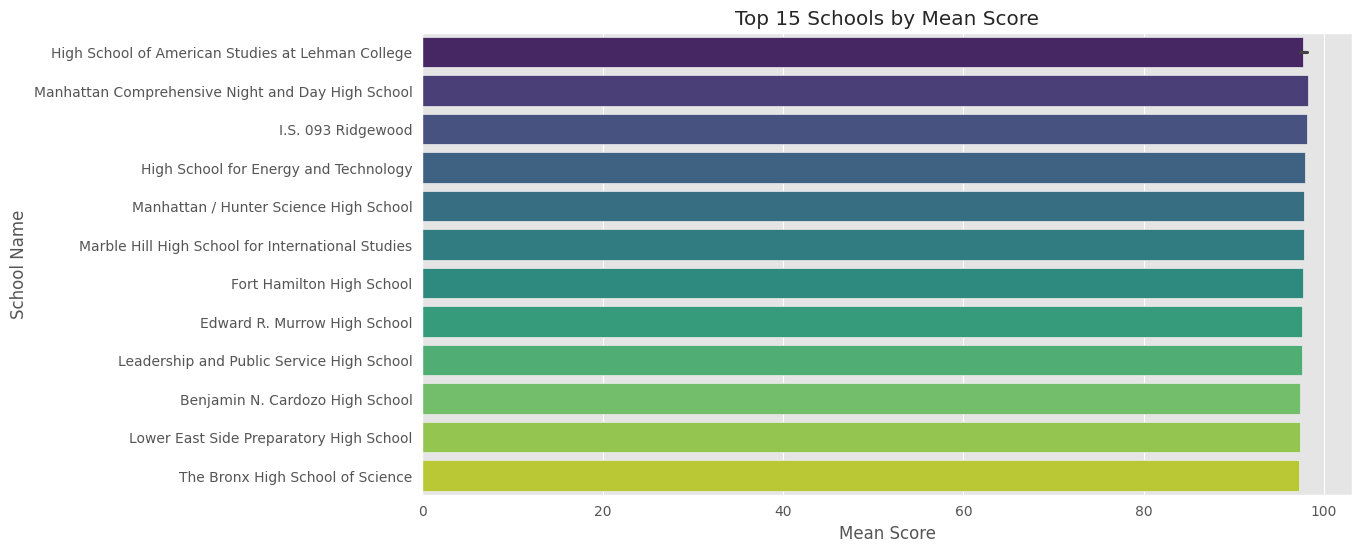

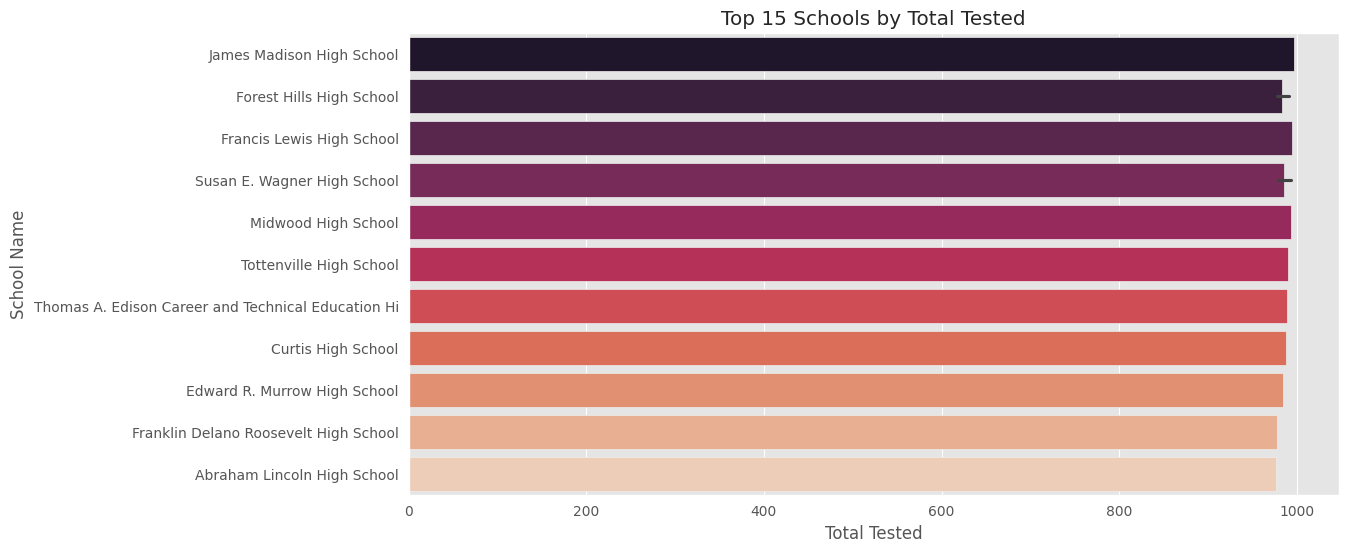

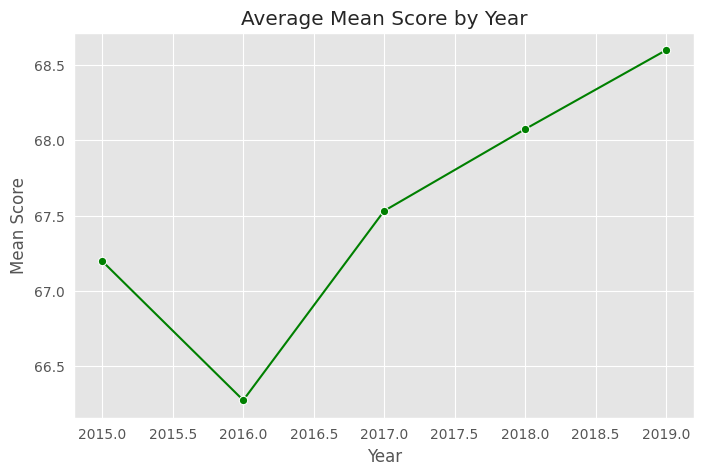

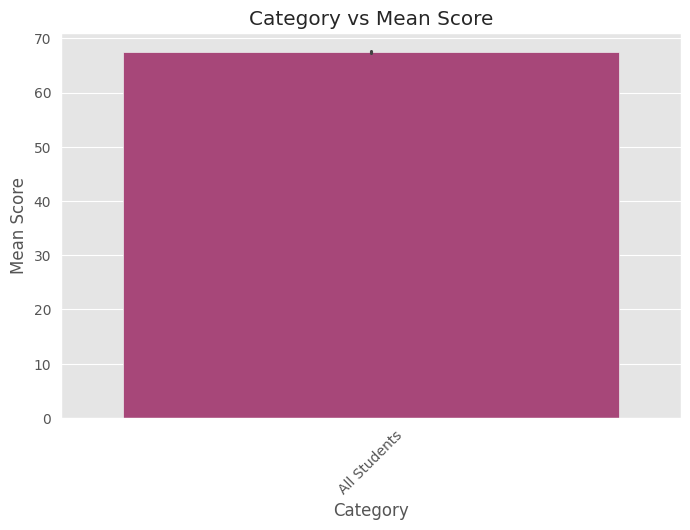

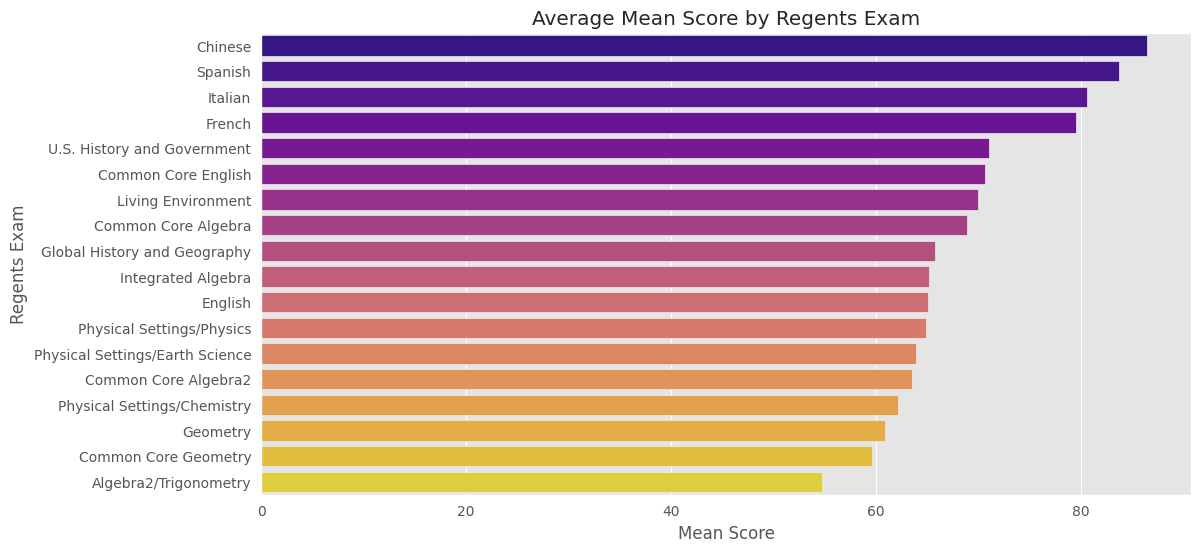

All visualizations completed successfully!


In [12]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# ============================================
# LOAD DATA
# ============================================


# Remove unnamed column if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print(df.head())
print(df.info())
print(df.describe(include="all"))

# ============================================
# HANDLE MISSING VALUES
# ============================================

df.replace(["s", "S", "NA", "N/A", ""], np.nan, inplace=True)

numeric_cols = [
    "Total Tested",
    "Mean Score",
    "Number Scoring Below 65",
    "Percent Scoring Below 65",
    "Number Scoring 65 or Above",
    "Percent Scoring 65 or Above",
    "Number Scoring 80 or Above",
    "Percent Scoring 80 or Above",
    "Number Scoring CR",
    "Percent Scoring CR"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================
# MISSING VALUE HEATMAP
# ============================================

plt.figure(figsize=(14,7))
sns.heatmap(df.isnull(), cmap="viridis", cbar=True)
plt.title("Missing Values Heatmap", fontsize=16)
plt.show()

# ============================================
# COUNTPLOT : SCHOOL TYPE
# ============================================

plt.figure(figsize=(8,5))
sns.countplot(
    x="School Type",
    data=df,
    palette="Set2"
)
plt.title("School Type Distribution")
plt.xticks(rotation=30)
plt.show()

# ============================================
# SCHOOL LEVEL
# ============================================

plt.figure(figsize=(8,5))
sns.countplot(
    x="School Level",
    data=df,
    palette="Dark2"
)
plt.title("School Level Distribution")
plt.xticks(rotation=30)
plt.show()

# ============================================
# REGENTS EXAM
# ============================================

plt.figure(figsize=(12,6))
sns.countplot(
    y="Regents Exam",
    data=df,
    palette="Paired",
    order=df["Regents Exam"].value_counts().index
)
plt.title("Number of Records for Each Regents Exam")
plt.show()

# ============================================
# CATEGORY
# ============================================

plt.figure(figsize=(8,5))
sns.countplot(
    x="Category",
    data=df,
    palette="Accent"
)
plt.title("Category Distribution")
plt.xticks(rotation=45)
plt.show()

# ============================================
# YEAR DISTRIBUTION
# ============================================

plt.figure(figsize=(7,5))
sns.countplot(
    x="Year",
    data=df,
    palette="cubehelix"
)
plt.title("Year Distribution")
plt.show()

# ============================================
# HISTOGRAM : MEAN SCORE
# ============================================

plt.figure(figsize=(9,5))
sns.histplot(
    df["Mean Score"],
    bins=30,
    kde=True,
    color="royalblue"
)
plt.title("Mean Score Distribution")
plt.show()

# ============================================
# HISTOGRAM : TOTAL TESTED
# ============================================

plt.figure(figsize=(9,5))
sns.histplot(
    df["Total Tested"],
    bins=40,
    kde=True,
    color="orange"
)
plt.title("Total Tested Distribution")
plt.show()

# ============================================
# BOXPLOT : MEAN SCORE
# ============================================

plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["Mean Score"],
    color="lightgreen"
)
plt.title("Mean Score Boxplot")
plt.show()

# ============================================
# BOXPLOT : TOTAL TESTED
# ============================================

plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["Total Tested"],
    color="tomato"
)
plt.title("Total Tested Boxplot")
plt.show()

# ============================================
# BOXPLOT SCHOOL TYPE VS MEAN SCORE
# ============================================

plt.figure(figsize=(10,6))
sns.boxplot(
    x="School Type",
    y="Mean Score",
    data=df,
    palette="Set3"
)
plt.title("School Type vs Mean Score")
plt.xticks(rotation=30)
plt.show()

# ============================================
# BOXPLOT SCHOOL LEVEL
# ============================================

plt.figure(figsize=(10,6))
sns.boxplot(
    x="School Level",
    y="Mean Score",
    data=df,
    palette="Pastel1"
)
plt.title("School Level vs Mean Score")
plt.xticks(rotation=30)
plt.show()

# ============================================
# VIOLIN PLOT
# ============================================

plt.figure(figsize=(10,6))
sns.violinplot(
    x="School Type",
    y="Mean Score",
    data=df,
    palette="coolwarm"
)
plt.title("Mean Score Distribution by School Type")
plt.xticks(rotation=30)
plt.show()

# ============================================
# SCATTERPLOT
# ============================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Total Tested",
    y="Mean Score",
    hue="School Type",
    data=df,
    palette="tab10"
)
plt.title("Total Tested vs Mean Score")
plt.show()

# ============================================
# REGRESSION PLOT
# ============================================

plt.figure(figsize=(8,6))
sns.regplot(
    x="Total Tested",
    y="Mean Score",
    data=df,
    scatter_kws={"color":"purple"},
    line_kws={"color":"red"}
)
plt.title("Regression Plot")
plt.show()

# ============================================
# PIE CHART SCHOOL TYPE
# ============================================

school_counts = df["School Type"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    school_counts,
    labels=school_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set3")
)
plt.title("School Type Percentage")
plt.show()

# ============================================
# PIE CHART CATEGORY
# ============================================

category_counts = df["Category"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Pastel2")
)
plt.title("Category Percentage")
plt.show()

# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(12,8))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Spectral",
    linewidths=1
)

plt.title("Correlation Heatmap")
plt.show()

# ============================================
# PAIRPLOT
# ============================================

sns.pairplot(
    df[numeric_cols].dropna(),
    corner=True,
    palette="husl"
)

plt.show()

# ============================================
# TOP 15 SCHOOLS BY MEAN SCORE
# ============================================

top = (
    df.sort_values("Mean Score", ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="Mean Score",
    y="School Name",
    data=top,
    palette="viridis"
)

plt.title("Top 15 Schools by Mean Score")
plt.show()

# ============================================
# TOP 15 SCHOOLS BY TOTAL TESTED
# ============================================

top_test = (
    df.sort_values("Total Tested", ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="Total Tested",
    y="School Name",
    data=top_test,
    palette="rocket"
)

plt.title("Top 15 Schools by Total Tested")
plt.show()

# ============================================
# LINEPLOT YEAR VS MEAN SCORE
# ============================================

year_mean = (
    df.groupby("Year")["Mean Score"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    x="Year",
    y="Mean Score",
    data=year_mean,
    marker="o",
    color="green"
)

plt.title("Average Mean Score by Year")
plt.show()

# ============================================
# BARPLOT CATEGORY VS MEAN SCORE
# ============================================

plt.figure(figsize=(8,5))

sns.barplot(
    x="Category",
    y="Mean Score",
    data=df,
    palette="magma"
)

plt.title("Category vs Mean Score")
plt.xticks(rotation=45)
plt.show()

# ============================================
# BARPLOT REGENTS EXAM
# ============================================

exam_mean = (
    df.groupby("Regents Exam")["Mean Score"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="Mean Score",
    y="Regents Exam",
    data=exam_mean,
    palette="plasma"
)

plt.title("Average Mean Score by Regents Exam")
plt.show()

print("All visualizations completed successfully!")

## Features Engineering

Training set size: 21960
Testing set size:  7320

=== RANDOM FOREST CLASSIFIER ===
Accuracy: 0.7395
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.85      0.79      4250
           1       0.73      0.59      0.66      3070

    accuracy                           0.74      7320
   macro avg       0.74      0.72      0.72      7320
weighted avg       0.74      0.74      0.73      7320

----------------------------------------
=== LOGISTIC REGRESSION ===
Accuracy: 0.5837
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.82      0.70      4250
           1       0.51      0.26      0.34      3070

    accuracy                           0.58      7320
   macro avg       0.56      0.54      0.52      7320
weighted avg       0.56      0.58      0.55      7320



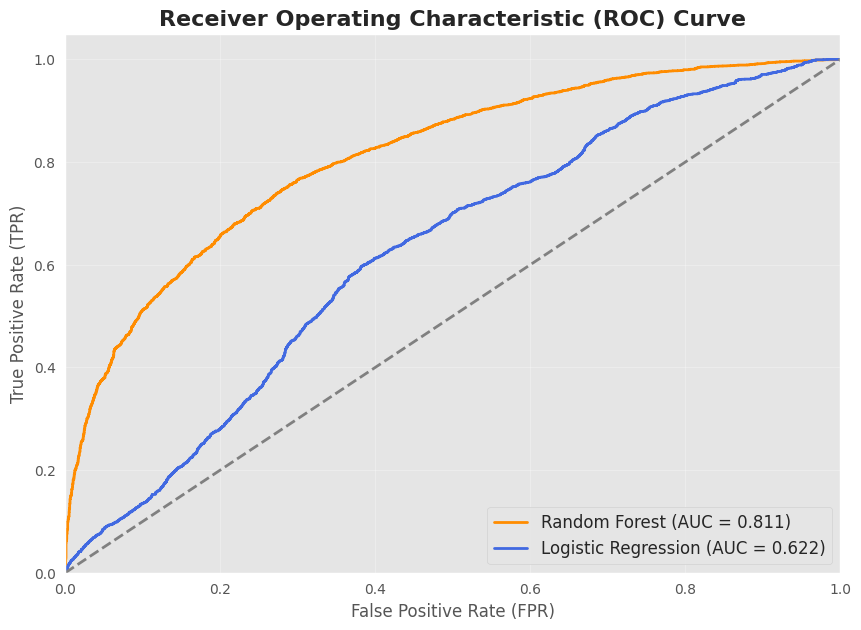

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# ==========================================
# 1. PREPARE THE DATA & DEFINE TARGET
# ==========================================
# (Assuming your dataframe is named 'df')

# Drop the unnamed column if it exists
if 'Unnamed Column' in df.columns:
    df = df.drop(columns=['Unnamed Column'])

# Ensure numeric columns are actually numeric
df['Percent Scoring 65 or Above'] = pd.to_numeric(df['Percent Scoring 65 or Above'], errors='coerce')
df['Total Tested'] = pd.to_numeric(df['Total Tested'], errors='coerce')

# Drop rows where our target basis is missing
df = df.dropna(subset=['Percent Scoring 65 or Above', 'Total Tested'])

# CREATE TARGET: 1 if >= 70% passed, 0 if < 70% passed
df['Target_High_Performing'] = (df['Percent Scoring 65 or Above'] >= 70.0).astype(int)

# DROP LEAKY COLUMNS and identifiers
# We cannot keep ANY result metrics, otherwise the model cheats (Data Leakage)
leaky_cols = [
    'School DBN', 'School Name', 'Mean Score', 
    'Number Scoring Below 65', 'Percent Scoring Below 65',
    'Number Scoring 65 or Above', 'Percent Scoring 65 or Above',
    'Number Scoring 80 or Above', 'Percent Scoring 80 or Above',
    'Number Scoring CR', 'Percent Scoring CR'
]
df = df.drop(columns=leaky_cols)

# Separate Features (X) and Target (y)
X = df.drop(columns=['Target_High_Performing'])
y = df['Target_High_Performing']

# ==========================================
# 2. TRAIN-TEST SPLIT (Done BEFORE encoding to prevent leakage)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size:  {X_test.shape[0]}\n")

# ==========================================
# 3. LABEL ENCODING (Fit on Train, Transform on Test)
# ==========================================
# We isolate the categorical columns that need encoding
categorical_cols = ['School Type', 'School Level', 'Regents Exam', 'Category']

# Dictionary to hold the encoders just in case we need to decode later
label_encoders = {}

for col in categorical_cols:
    # Convert everything to string to prevent mixed-type errors
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)
    
    le = LabelEncoder()
    # Fit ONLY on training data
    X_train[col] = le.fit_transform(X_train[col])
    
    # Transform test data safely (handling unseen categories by mapping them to an 'unknown' class)
    # This prevents errors if the test set has a category not seen in the training set
    classes = list(le.classes_)
    X_test[col] = X_test[col].apply(lambda x: classes.index(x) if x in classes else len(classes))
    
    label_encoders[col] = le

# ==========================================
# 4. APPLY MACHINE LEARNING ALGORITHMS
# ==========================================
# Model A: Random Forest (Great for categorical/encoded data)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Model B: Logistic Regression (Needs scaled data technically, but we'll run it as a baseline)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# ==========================================
# 5. DETAILED ACCURACY REPORT
# ==========================================
print("=== RANDOM FOREST CLASSIFIER ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print("Detailed Classification Report:")
print(classification_report(y_test, rf_preds))
print("-" * 40)

print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print("Detailed Classification Report:")
print(classification_report(y_test, lr_preds))

# ==========================================
# 6. ROC CURVE VISUALIZATION
# ==========================================
# Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = auc(lr_fpr, lr_tpr)

# Plotting
plt.figure(figsize=(10, 7))
plt.plot(rf_fpr, rf_tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(lr_fpr, lr_tpr, color='royalblue', lw=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')

# Diagonal line representing a random guess
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

## Thanks.......Please Upvote